## Imports

In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

from mdm2_breaker import (
    GraphSiameseNetwork,
    ProteinFeaturizer,
    SmallMoleculeFeaturizer_v5,
    generate_scaffold_split,
    plot_loss,
    train_model,
    view_protein,
    visualize_scaffold_split,
    load_model_from_checkpoint,
    plot_predictions
)

ROOT = Path(os.getcwd()).parents[0]

## Constants

In [2]:
pdb_file = os.path.join(ROOT, "data", "MDM2_Breaker", "raw", "1YCR.pdb")
mol_file = os.path.join(
    ROOT, "data", "MDM2_Breaker", "raw", "bindingdb_p53_binding_protein_mdm2.tsv"
)

In [3]:
EPOCHS = 100
LR = 1e-4

## Load Data

In [4]:
protein_data = ProteinFeaturizer(pdb_file=pdb_file)
view_protein(pdb_file)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [5]:
mol_data = SmallMoleculeFeaturizer_v5(
    root=os.path.join(ROOT, "data", "MDM2_Breaker"), file_path=mol_file
)
df_mol = pd.read_csv(mol_data.processed_paths[0].replace(".pt", ".csv"))

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)


def smile_to_fingerprint(smile):
    mol = Chem.MolFromSmiles(smile)
    if mol is None:
        return np.zeros((2048,), dtype=np.float32)

    # NEW CALL
    fp = mfpgen.GetFingerprintAsNumPy(mol)
    return fp


df_mol["fingerprint"] = df_mol["SMILES"].apply(smile_to_fingerprint)
df_mol.head(3)

,SMILES,IC50,Target,Organism,IC50_numeric,pIC50,pIC50_norm,fingerprint
0,COc1ccc(CO)cc1-c1nc2C(=O)N([C@H](c2n1C(C)C)c1c...,0.04,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.040,10.397940,1.862604,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,COc1ccc(cc1-c1nc2C(=O)N([C@H](c2n1C(C)C)c1ccc(...,0.05,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.050,10.301030,1.799189,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
2,COC[C@@H](C)n1c(nc2C(=O)N([C@H](c12)c1ccc(Cl)c...,0.059,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.059,10.229148,1.752152,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."


## Prepare Data for Modeling

#### Analyze Data to Ensure Minimal Structure Leak During Splitting

In [6]:
# Usage in your notebook:
train_indices, val_indices, test_indices = generate_scaffold_split(mol_data)

df_mol["split"] = "train"
df_mol.loc[val_indices, "split"] = "val"
df_mol.loc[test_indices, "split"] = "test"
df_mol.to_csv(
    os.path.join(ROOT, "data", "MDM2_Breaker", "processed", "benchmark_data.csv"),
    index=False,
)
print("Data exported to benchmark_data.csv")

Generating Scaffolds...
Split Complete.
Train: 3229 molecules
Val:   404 molecules
Test:  396 molecules
Data exported to benchmark_data.csv


Analyzing Train Set...
Analyzing Test Set...

--- Top 5 Training Scaffolds ---


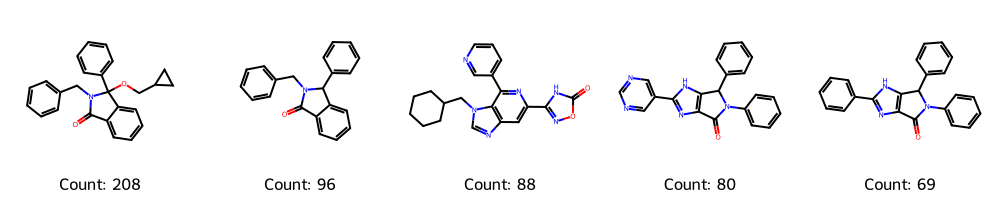


--- Top 5 Test Scaffolds (Should be different!) ---


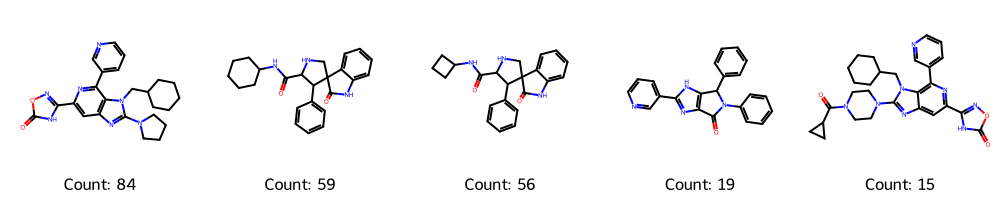


Computing t-SNE (this might take a moment)...


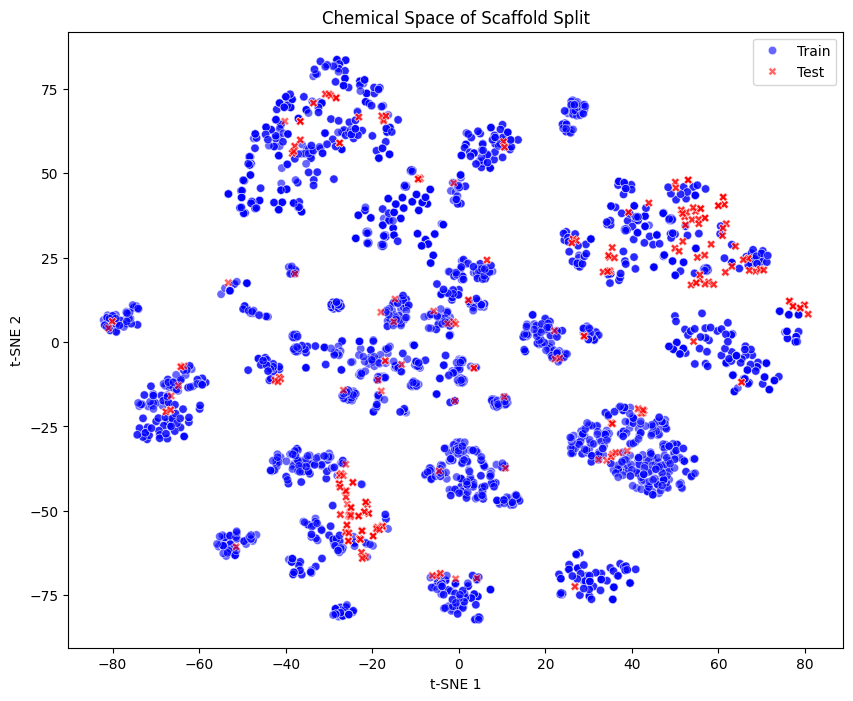

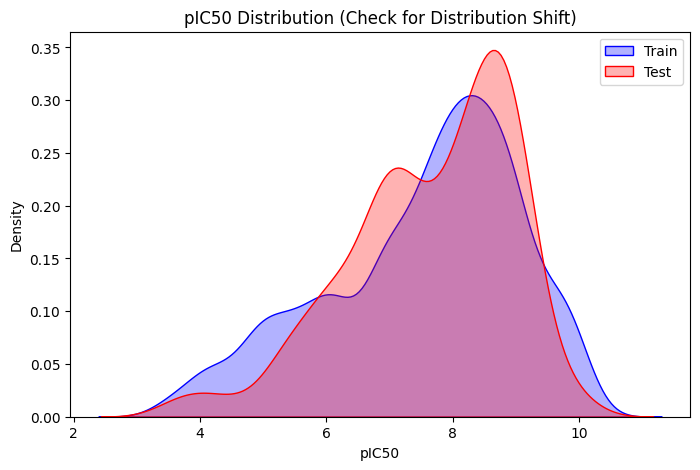

In [7]:
# Run it
visualize_scaffold_split(mol_data, train_indices, val_indices, test_indices)

### Compare with Random Splitting

Analyzing Train Set...
Analyzing Test Set...

--- Top 5 Training Scaffolds ---


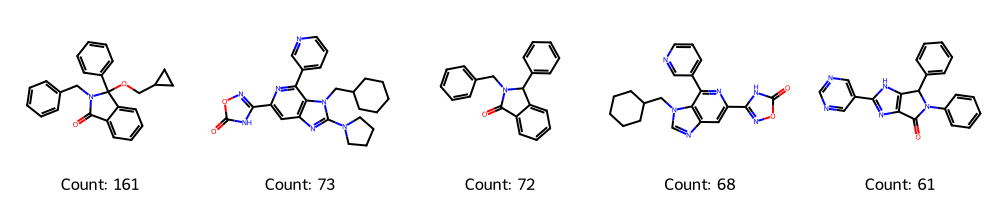


--- Top 5 Test Scaffolds (Should be different!) ---


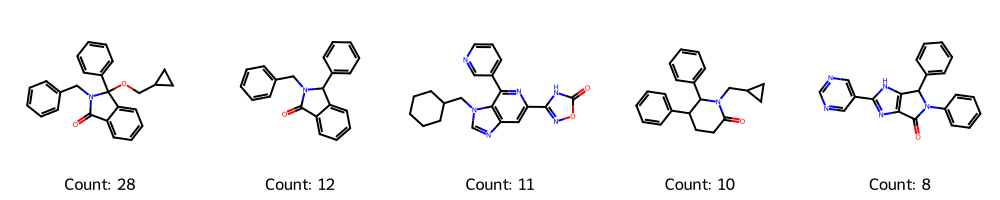


Computing t-SNE (this might take a moment)...


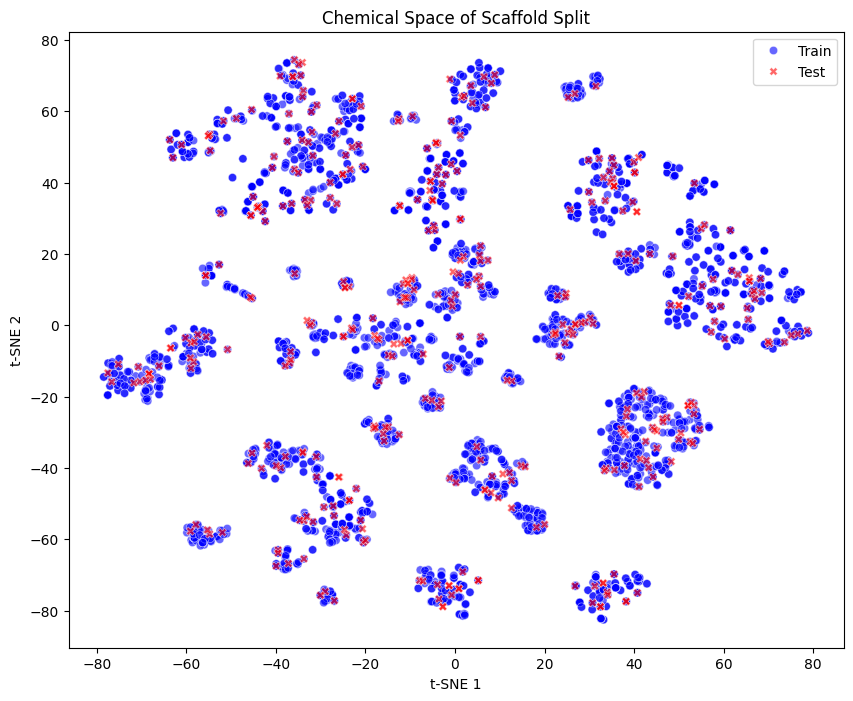

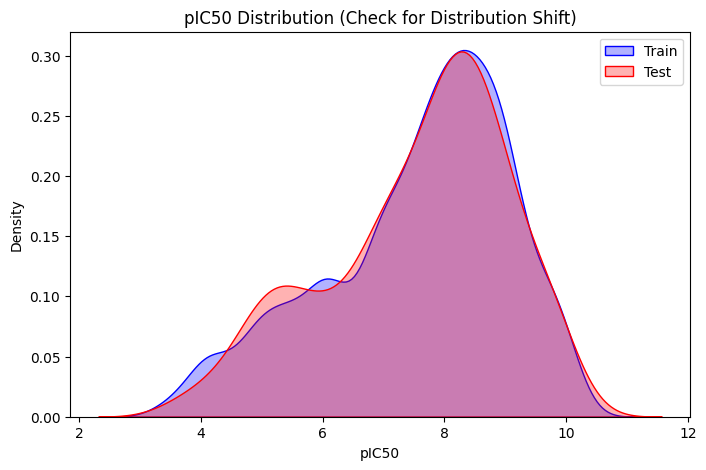

In [8]:
torch.manual_seed(42)  # Fixed seed for reproducibility
num_samples = len(mol_data)
indices = torch.randperm(num_samples).tolist()

train_size = int(0.8 * num_samples)
val_size = int(0.1 * num_samples)
test_size = num_samples - train_size - val_size

# Slice the Indices
train_indices_random = indices[:train_size]
val_indices_random = indices[train_size : train_size + val_size]
test_indices_random = indices[train_size + val_size :]

visualize_scaffold_split(
    mol_data, train_indices_random, val_indices_random, test_indices_random
)

## Modeling

### Graph Siamese Network - GATv2Conv Layers. Add Bond Attributes. Add Atom Features.

In [ ]:
model_v5, train_loader_v5, val_loader_v5, test_loader_v5 = train_model(
    model=GraphSiameseNetwork(molecular_encoding_type="gcn"),
    mol_class=SmallMoleculeFeaturizer_v5,
    protein_data=protein_data.get_graph(),
    train_indices=train_indices,
    val_indices=val_indices,
    test_indices=test_indices,
    epochs=EPOCHS,
    lr=LR,
    save_name="Model-v5_1-updated",
    train=False,
    mol_file=mol_file,
)

/Users/dantrainer/projects/cancer_research/src/mdm2_breaker/featurizers.py:92: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:264.)
  edge_index = torch.tensor([src, dst], dtype=torch.long)
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with

┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ GraphSiameseNetwork │  2.6 M │ train │     0 │
└───┴───────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 42                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

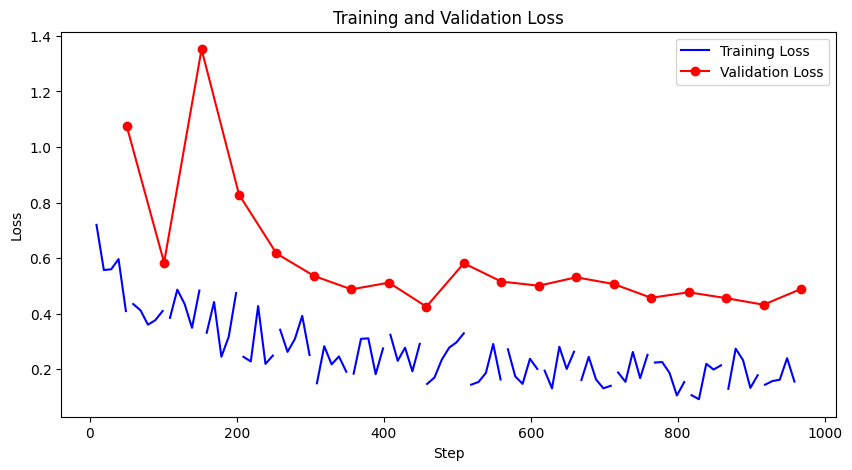

In [10]:
plot_loss("lightning_logs/version_17/metrics.csv")

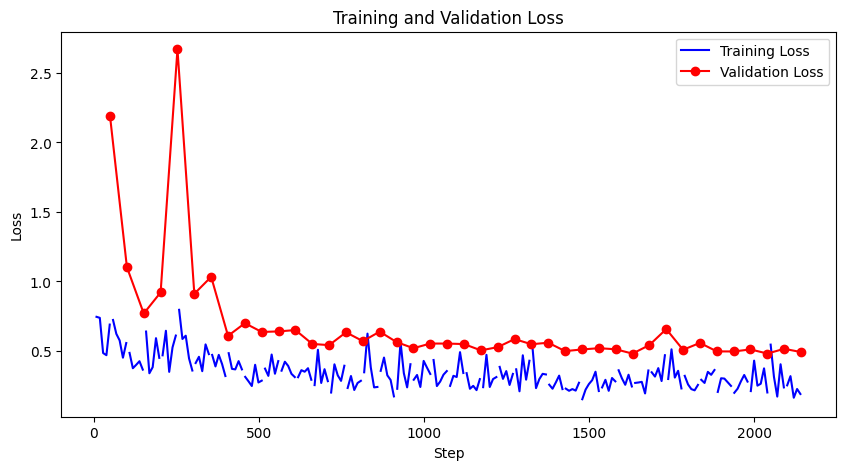

In [11]:
plot_loss("lightning_logs/version_18/metrics.csv")

In [ ]:
checkpoint_path = "checkpoints/Model-v5_1-updated-v2.ckpt"

# 1. Load the raw checkpoint
checkpoint = torch.load(checkpoint_path)
state_dict = checkpoint["state_dict"]

# 2. Fix the keys (Remove "model." prefix)
new_state_dict = {}
for key, value in state_dict.items():
    if key.startswith("model."):
        # Strip the first 6 characters ("model.")
        new_key = key[6:]
        new_state_dict[new_key] = value

# 3. Initialize your raw model
model = GraphSiameseNetwork(molecular_encoding_type="gcn")

# 4. Load the cleaned weights
model.load_state_dict(new_state_dict)
model.eval()

plot_predictions(
    model,
    (train_loader_v5, val_loader_v5, test_loader_v5),
    protein_data.get_graph(),
    "Model-v5_1-updated-v2",
)

Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.10/multiprocessing/spawn.py", line 116, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.10/multiprocessing/spawn.py", line 126, in _main
    self = reduction.pickle.load(from_parent)
  File "/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.10/site-packages/torch/multiprocessing/reductions.py", line 374, in rebuild_storage_filename
    storage = torch.UntypedStorage._new_shared_filename_cpu(manager, handle, size)
RuntimeError: Connection refused


Running t-SNE...


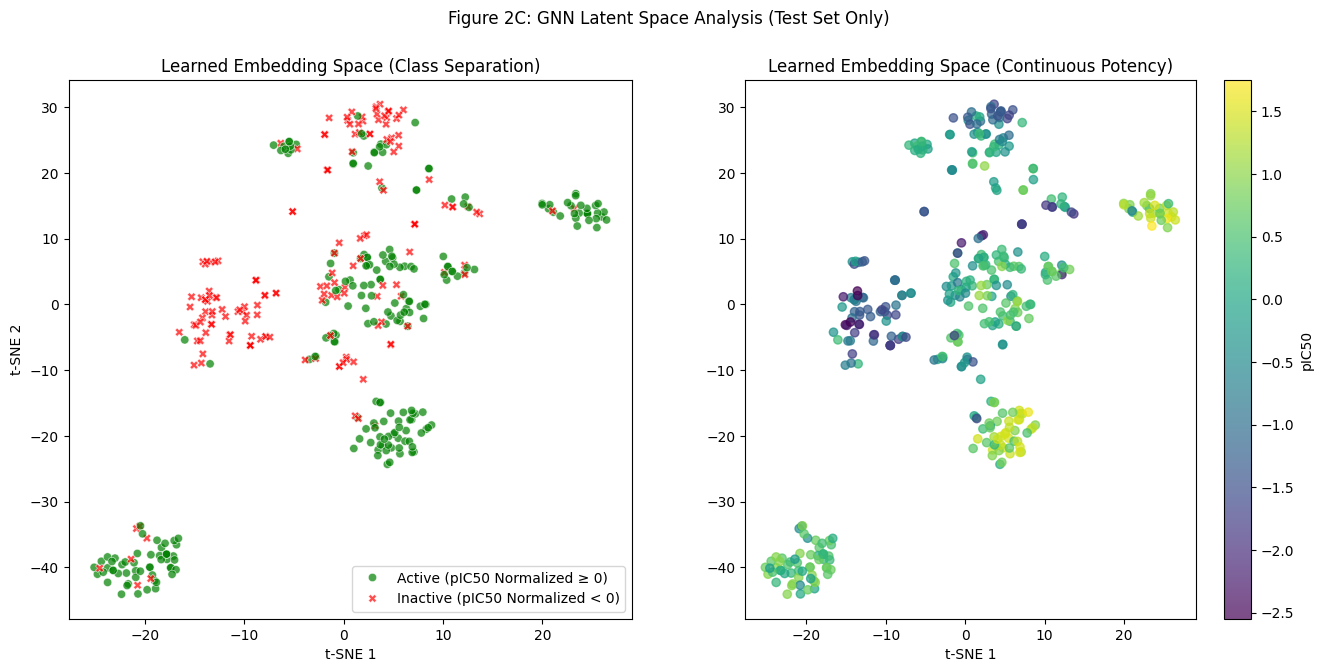

In [ ]:
def plot_latent_space(model, test_indices, mol_data):
    embeddings = []
    activities = []
    labels = []
    threshold = 0

    with torch.no_grad():
        for idx in test_indices:
            data = mol_data[idx]

            # 1. Extract the Molecule Embedding (Graph Part Only)
            # This corresponds to the 'mol_vec' in your forward pass
            # Shape: [1, 256] (128 sum + 128 max)
            mol_vec = model.encode_molecule(data)

            # Store as numpy
            embeddings.append(mol_vec.cpu().numpy())

            # Store Truth
            pIC50 = data.y.item()
            activities.append(pIC50)

            # Define Label
            if pIC50 >= threshold:
                labels.append(f"Active (pIC50 Normalized ≥ {threshold})")
            else:
                labels.append(f"Inactive (pIC50 Normalized < {threshold})")

        # Concatenate
        X = np.concatenate(embeddings, axis=0)
        y_continuous = np.array(activities)
        y_discrete = np.array(labels)

        # 2. Run t-SNE
        print("Running t-SNE...")
        tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto")
        X_embedded = tsne.fit_transform(X)

        # 3. Plotting
        fig, ax = plt.subplots(1, 2, figsize=(16, 7))

        # Plot A: Discrete (Active vs Inactive)
        sns.scatterplot(
            x=X_embedded[:, 0],
            y=X_embedded[:, 1],
            hue=y_discrete,
            style=y_discrete,
            palette={
                f"Active (pIC50 Normalized ≥ {threshold})": "green",
                f"Inactive (pIC50 Normalized < {threshold})": "red",
            },
            alpha=0.7,
            ax=ax[0],
        )
        ax[0].set_title("Learned Embedding Space (Class Separation)")
        ax[0].set_xlabel("t-SNE 1")
        ax[0].set_ylabel("t-SNE 2")

        # Plot B: Continuous (Gradient)
        sc = ax[1].scatter(
            X_embedded[:, 0],
            X_embedded[:, 1],
            c=y_continuous,
            cmap="viridis",
            alpha=0.7,
        )
        plt.colorbar(sc, ax=ax[1], label="pIC50")
        ax[1].set_title("Learned Embedding Space (Continuous Potency)")
        ax[1].set_xlabel("t-SNE 1")

        plt.suptitle("Figure 2C: GNN Latent Space Analysis (Test Set Only)")
        plt.show()


plot_latent_space(model_v5, test_indices_random, mol_data)

Running t-SNE...


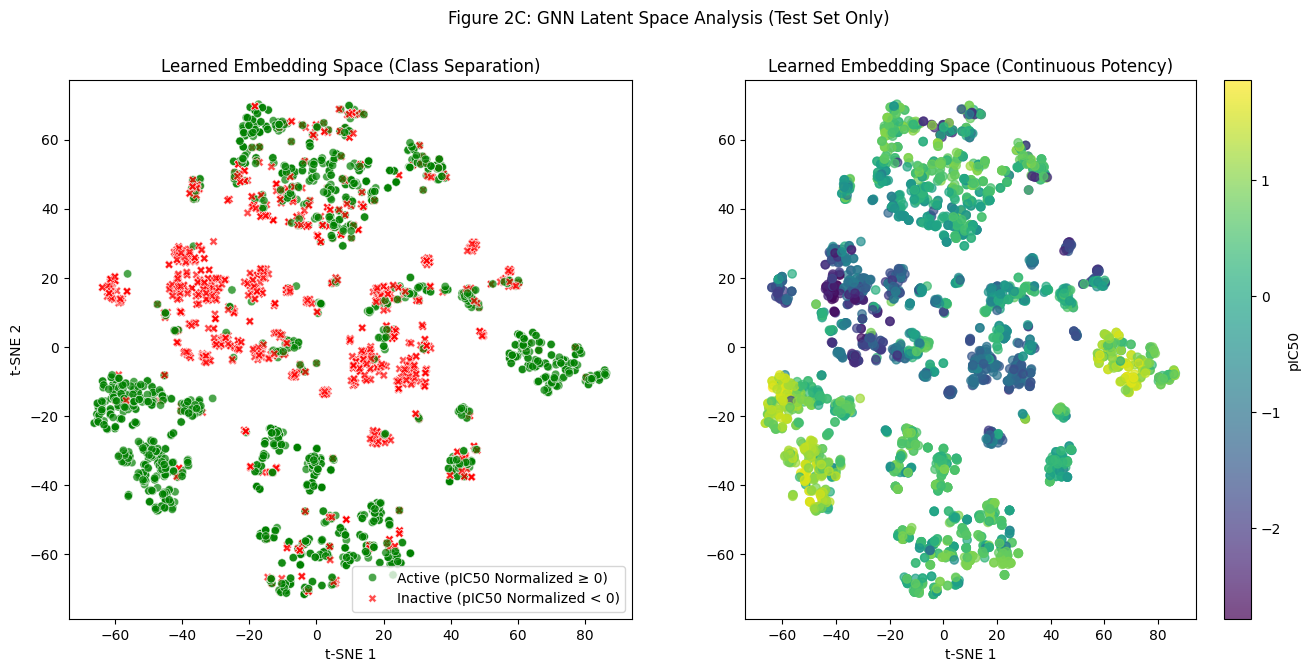

In [ ]:
plot_latent_space(model_v5, train_indices_random, mol_data)

Running t-SNE...


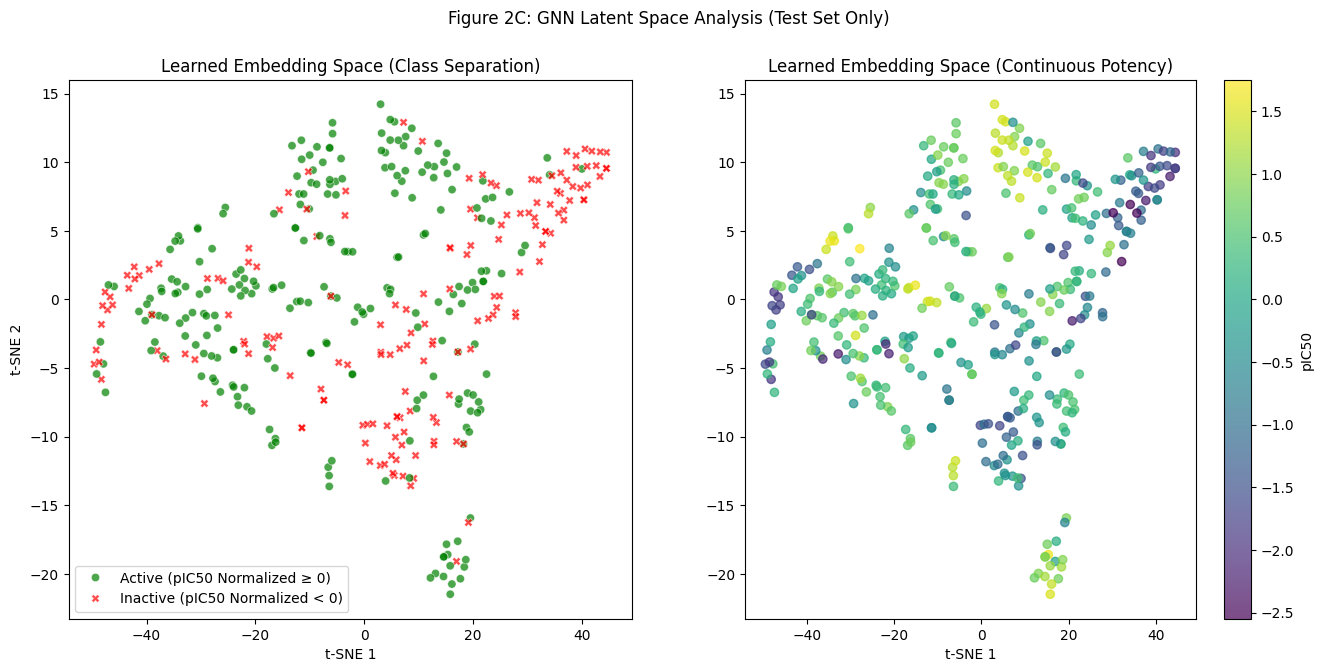

Running t-SNE...


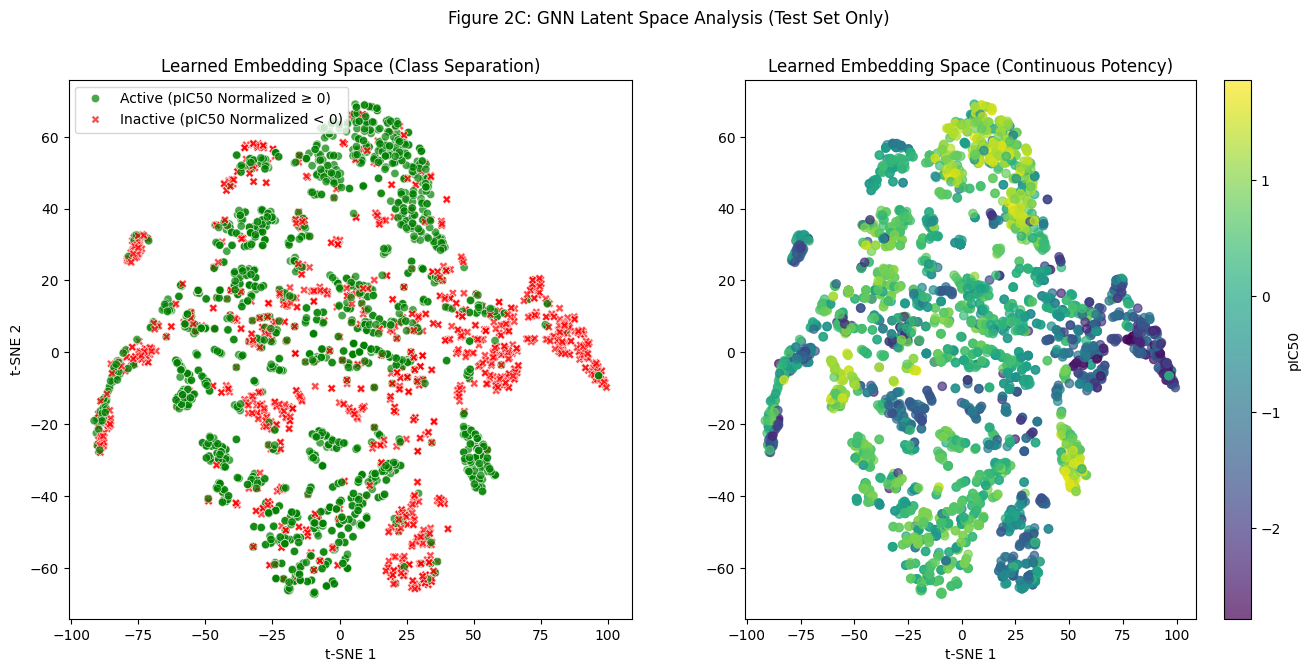

In [ ]:
untrained_model = GraphSiameseNetwork_v5()
plot_latent_space(untrained_model, test_indices_random, mol_data)
plot_latent_space(untrained_model, train_indices_random, mol_data)

## XGBoost

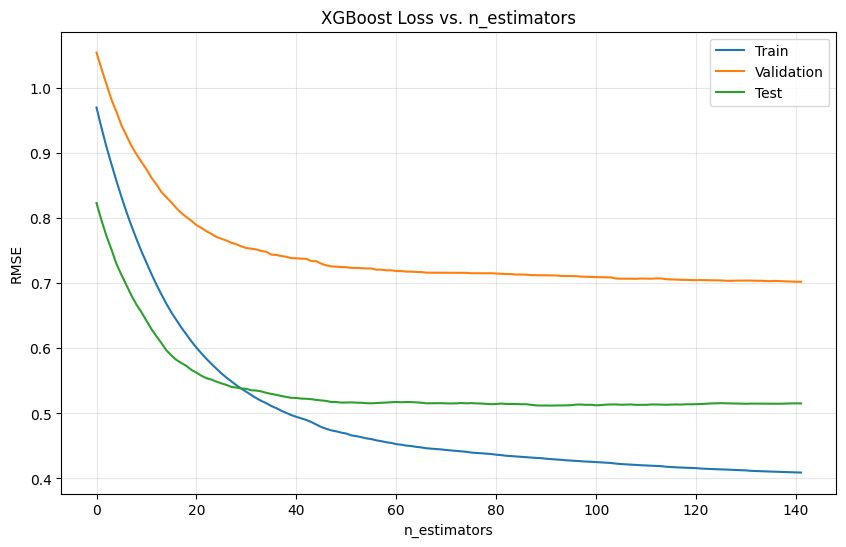

Best Iteration: 91
Best Score (Validation MSE): 0.5118


In [ ]:
import xgboost as xgb

# Apply to the CSV for XGBoost
train_df = df_mol.iloc[train_indices]
val_df = df_mol.iloc[val_indices]
test_df = df_mol.iloc[test_indices]

xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    early_stopping_rounds=50,
)

X_test = np.stack(np.array(test_df["fingerprint"]))
y_test = test_df["pIC50_norm"].values
X_train = np.stack(np.array(train_df["fingerprint"]))
y_train = train_df["pIC50_norm"].values
X_val = np.stack(np.array(val_df["fingerprint"]))
y_val = val_df["pIC50_norm"].values

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val), (X_test, y_test)],
    verbose=False,
)

y_pred_train = xgb_model.predict(X_train)
y_pred_val = xgb_model.predict(X_val)
y_pred_test = xgb_model.predict(X_test)

mse_train = np.mean((y_pred_train - y_train) ** 2)
mse_val = np.mean((y_pred_val - y_val) ** 2)
mse_test = np.mean((y_pred_test - y_test) ** 2)

plot_xgb_loss(xgb_model)

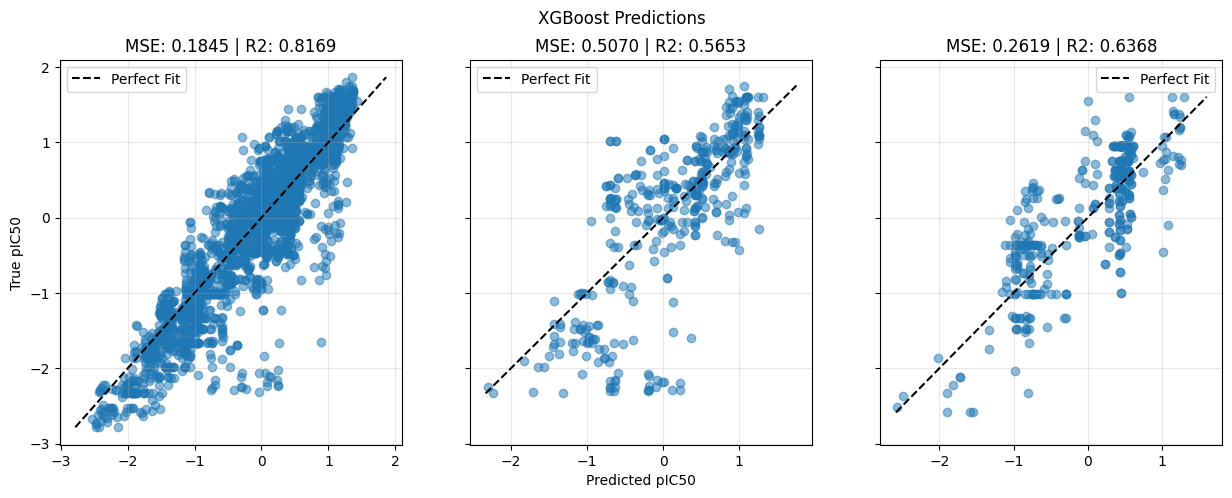

In [ ]:
plot_xgboost_predictions(
    pred_train_mse_tuple=(y_pred_train, y_train, mse_train),
    pred_val_mse_tuple=(y_pred_val, y_val, mse_val),
    pred_test_mse_tuple=(y_pred_test, y_test, mse_test),
)
del xgb_model, y_pred_train, y_pred_val, y_pred_test, mse_train, mse_val, mse_test

## Check Autodock-Vina Benchmark

In [ ]:
import os
import subprocess

import numpy as np
import pandas as pd


class AutoDockRunner:
    def __init__(self, receptor_pdb_path, work_dir="vina_benchmark"):
        self.receptor_pdb = receptor_pdb_path
        self.work_dir = work_dir
        self.receptor_pdbqt = os.path.join(work_dir, "receptor.pdbqt")

        os.makedirs(work_dir, exist_ok=True)

    def prepare_receptor(self):
        """
        Converts the PDB receptor to PDBQT format using OpenBabel.
        Note: For a 'Scientific Leader' grade benchmark, you'd usually use
        MGLTools to handle protonation carefully, but OpenBabel is standard for high-throughput baselines.
        """
        print(f"Converting Receptor {self.receptor_pdb} to PDBQT...")
        # -xr: rigid molecule, -h: add hydrogens
        cmd = f"obabel {self.receptor_pdb} -O {self.receptor_pdbqt} -xr -h --partialcharge gasteiger"
        subprocess.run(cmd, shell=True, check=True)

    def get_pocket_center(self, pdb_file):
        """
        Calculates the center of the binding pocket based on the bound ligand (p53 peptide chain B).
        Crucial: Vina needs to know WHERE to look.
        """
        # Simple parser to find Chain B (the p53 peptide in 1YCR)
        coords = []
        # Inside get_pocket_center
        target_residues = {"19", "23", "26"}  # PDB residue numbers for Phe, Trp, Leu
        coords = []
        with open(pdb_file, "r") as f:
            for line in f:
                if line.startswith("ATOM") and line[21] == "B":
                    res_seq = line[22:26].strip()
                    if res_seq in target_residues:
                        x = float(line[30:38])
                        y = float(line[38:46])
                        z = float(line[46:54])
                        coords.append([x, y, z])

        if not coords:
            print(
                "Warning: Could not find Chain B (peptide) to define pocket center. Using geometric center."
            )
            # Fallback logic if needed
            return [0, 0, 0]

        center = np.mean(coords, axis=0)
        print(f"Calculated Pocket Center: {center}")
        return center

    def prepare_ligand(self, smiles, lig_id):
        """
        1. Generates 3D Conformer with RDKit
        2. Converts to PDBQT with OpenBabel
        """
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None

        mol = Chem.AddHs(mol)
        try:
            # Generate 3D coordinates
            AllChem.MMFFOptimizeMolecule(mol)
            res = AllChem.EmbedMolecule(mol, AllChem.ETKDG())
            if res == -1:
                # Try with random coords if ETKDG fails
                res = AllChem.EmbedMolecule(mol, AllChem.ETKDG(), useRandomCoords=True)
                if res == -1:
                    return None  # Give up if both fail
        except:
            return None

        # Save temp SDF
        sdf_path = os.path.join(self.work_dir, f"lig_{lig_id}.sdf")
        pdbqt_path = os.path.join(self.work_dir, f"lig_{lig_id}.pdbqt")

        writer = Chem.SDWriter(sdf_path)
        writer.write(mol)
        writer.close()

        # Convert to PDBQT
        cmd = f"obabel {sdf_path} -O {pdbqt_path} -h --partialcharge gasteiger"
        subprocess.run(cmd, shell=True, stderr=subprocess.DEVNULL)

        return pdbqt_path

    def run_vina(self, lig_pdbqt, center, size=(20, 20, 20)):
        """
        Runs Vina and parses the best affinity score.
        """
        out_pdbqt = lig_pdbqt.replace(".pdbqt", "_out.pdbqt")
        log_file = lig_pdbqt.replace(".pdbqt", ".log")

        # Construct Vina Command
        # exhaustiveness=8 is default. Increase to 32 for "Paper Quality" results (slower)
        cmd = (
            f"vina --receptor {self.receptor_pdbqt} --ligand {lig_pdbqt} "
            f"--center_x {center[0]} --center_y {center[1]} --center_z {center[2]} "
            f"--size_x {size[0]} --size_y {size[1]} --size_z {size[2]} "
            f"--exhaustiveness 8 --out {out_pdbqt} > {log_file}"
        )

        try:
            subprocess.run(cmd, shell=True, check=True)

            # Parse the Log file for the best score (Top mode)
            with open(log_file, "r") as f:
                for line in f:
                    if line.strip().startswith("1"):
                        # Output format: mode | affinity | dist...
                        # Example:   1        -9.4      0.000
                        parts = line.split()
                        if len(parts) >= 2:
                            return float(parts[1])  # The Affinity (kcal/mol)
        except Exception as e:
            print(f"Vina failed: {e}")
            return None

        return None


In [ ]:
# # --- EXECUTION ---
# # 1. Initialize
# runner = AutoDockRunner(receptor_pdb_path=os.path.join(ROOT, "data", "MDM2_Breaker", "raw", "1YCR.pdb"))
# runner.prepare_receptor()
# pocket_center = runner.get_pocket_center(runner.receptor_pdb)

In [ ]:
# # 2. Run on Test Set (Select a subset of ~50-100 molecules to save time)
# # Full Vina runs can take 10-30 seconds per molecule.

# vina_results = []
# for idx in tqdm(test_indices):
#     smiles = df_mol.iloc[idx]['SMILES']
#     true_pic50 = df_mol.iloc[idx]['pIC50']

#     # Prep & Dock
#     lig_path = runner.prepare_ligand(smiles, idx)
#     if lig_path:
#         score = runner.run_vina(lig_path, pocket_center)
#         if score is not None:
#             vina_results.append({
#                 "idx": idx,
#                 "SMILES": smiles,
#                 "Vina_Affinity_kcal": score,
#                 "True_pIC50": true_pic50
#             })

# # 3. Analyze
# df_vina = pd.DataFrame(vina_results)
# df_vina.to_csv("vina_results.csv", index=False)
# print("Done!")

In [ ]:
def vina_to_pic50(delta_g_kcal):
    """
    Converts AutoDock Vina score (kcal/mol) to pIC50.
    Assumes T = 298.15 K.
    """
    R = 1.98720425864083e-3  # Gas constant in kcal/(mol·K)
    T = 298.15  # Temperature in Kelvin

    # 1. Convert Delta G to Ki (Molar)
    # Ki = exp(DeltaG / RT)
    ki_molar = np.exp(delta_g_kcal / (R * T))

    # 2. Convert Ki to pIC50
    # pIC50 = -log10(Ki)
    pic50 = -np.log10(ki_molar)

    return pic50

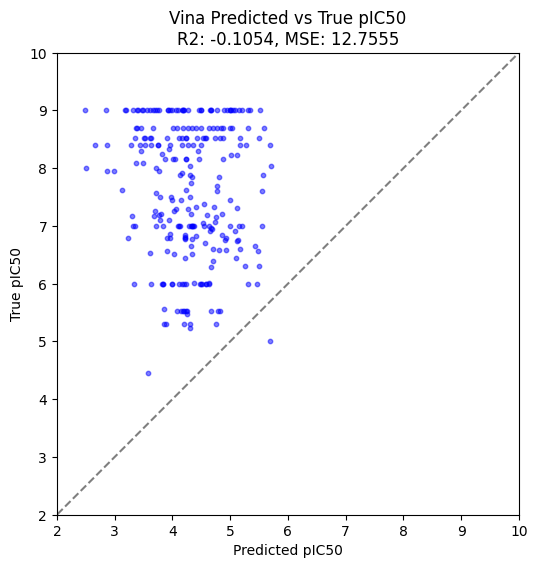

In [ ]:
import numpy as np
import pandas as pd

df_vina = pd.read_csv("vina_results.csv")
df_vina["vina_pred_pic50"] = df_vina["Vina_Affinity_kcal"].apply(vina_to_pic50)

_, ax = plt.subplots(1, 1, figsize=(6, 6))
df_vina.plot(
    x="vina_pred_pic50",
    y="True_pIC50",
    kind="scatter",
    alpha=0.5,
    color="blue",
    s=10,
    ax=ax,
)
r2 = df_vina["vina_pred_pic50"].corr(df_vina["True_pIC50"])
mse = np.mean((df_vina["vina_pred_pic50"] - df_vina["True_pIC50"]) ** 2)
plt.xlim(2, 10)
plt.ylim(2, 10)
ax.set_aspect("equal", "box")
plt.plot([0, 14], [0, 14], "k--", alpha=0.5)
plt.xlabel("Predicted pIC50")
plt.ylabel("True pIC50")
plt.title(f"Vina Predicted vs True pIC50\nR2: {r2:.4f}, MSE: {mse:.4f}")
plt.show()


## Check Graph DTA

In [ ]:
# 1. Create the new Sequence Encoder (Freshly initialized)
seq_encoder = ProteinSequenceEncoder(output_dim=128)
uninitialized_graph_model = GraphSiameseNetwork_v5(molecular_encoding_type="gcn")
# 2. Assemble the Hybrid Model
# Note: We pass 'model_v5.encode_molecule' as the encoder function
hybrid_model = SequenceSiameseNetwork(
    molecule_encoder=uninitialized_graph_model.encode_molecule,
    sequence_encoder=seq_encoder,
)

# # 4. (Optional) Freeze the Molecule side to test purely the Protein Signal
for param in hybrid_model.parameters():
    param.requires_grad = True

In [ ]:
def train_model(
    model,
    mol_class,
    protein_data,
    train_indices,
    val_indices,
    test_indices,
    epochs=100,
    lr=1e-4,
    save_name="sarcoma-model-{epoch:02d}-{val_loss:.2f}",
):
    trainer = define_trainer(epochs=epochs, lr=lr, save_name=save_name)

    train_loader, val_loader, test_loader = generate_loaders(
        mol_class, train_indices, val_indices, test_indices
    )

    system = SarcomaScoutSystem(model=model, protein_data=protein_data, lr=lr)

    trainer.fit(system, train_loader, val_loader)

    return model, train_loader, val_loader, test_loader

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/dantrainer/projects/cancer_research/notebooks/checkpoints exists and is not empty.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ SequenceSiameseNetwork │  1.1 M │ train │     0 │
└───┴───────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 1.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.1 M                                                                                                
Total estimated model params size (MB): 4                                                                          
Modules in train mode: 17                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

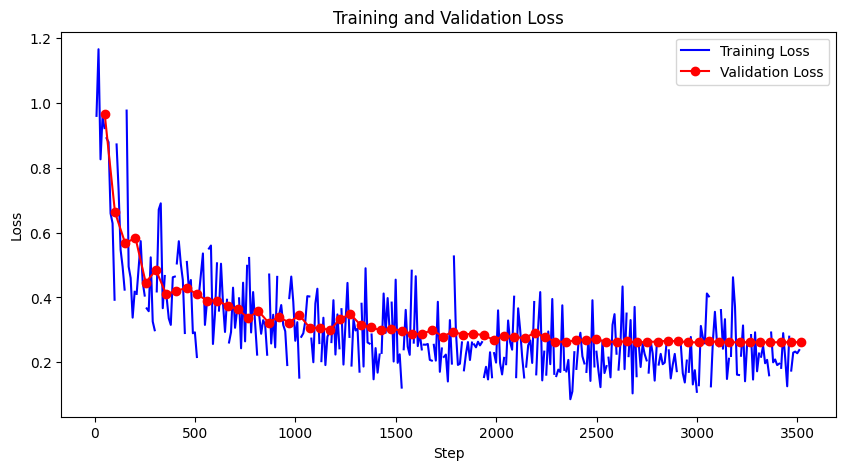

In [ ]:
MDM2_SEQUENCE = "SQIPASEQETLVRPKPLLLKLLKSVGAQKDTYTMKEVLFYLGQYIMTKRLYDEKQQHIVYCSNDLLGDLFGVPSFSVKEHRKIYTMIYRNLVVVNQQESSDSGTSVSEN"

# Simple Amino Acid Vocabulary
AA_VOCAB = "ACDEFGHIKLMNPQRSTVWY"  # The 20 standard
char_to_int = {c: i + 1 for i, c in enumerate(AA_VOCAB)}  # Start at 1, 0 is padding


def tokenize_sequence(seq, max_len=1000):
    # Convert chars to ints, ignoring unknown chars
    indices = [char_to_int.get(c, 0) for c in seq]

    # Pad or Truncate
    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices))
    else:
        indices = indices[:max_len]

    return torch.tensor(indices, dtype=torch.long)


# Usage
mdm2_tensor = tokenize_sequence(MDM2_SEQUENCE).unsqueeze(0)  # Add batch dim

model_gdta, train_loader_gdta, val_loader_gdta, test_loader_gdta = train_model(
    model=hybrid_model,
    mol_class=SmallMoleculeFeaturizer_v5,
    protein_data=mdm2_tensor,
    train_indices=train_indices,
    val_indices=val_indices,
    test_indices=test_indices,
    epochs=EPOCHS,
    lr=LR,
    save_name="Model-GraphDTA_from_scratch_v2",
)
plot_loss("lightning_logs/version_15/metrics.csv")

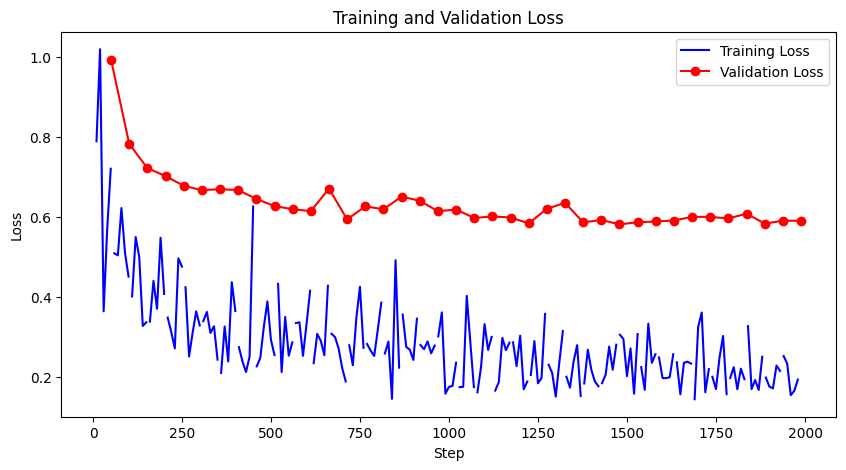

In [ ]:
plot_loss("lightning_logs/version_15/metrics.csv")

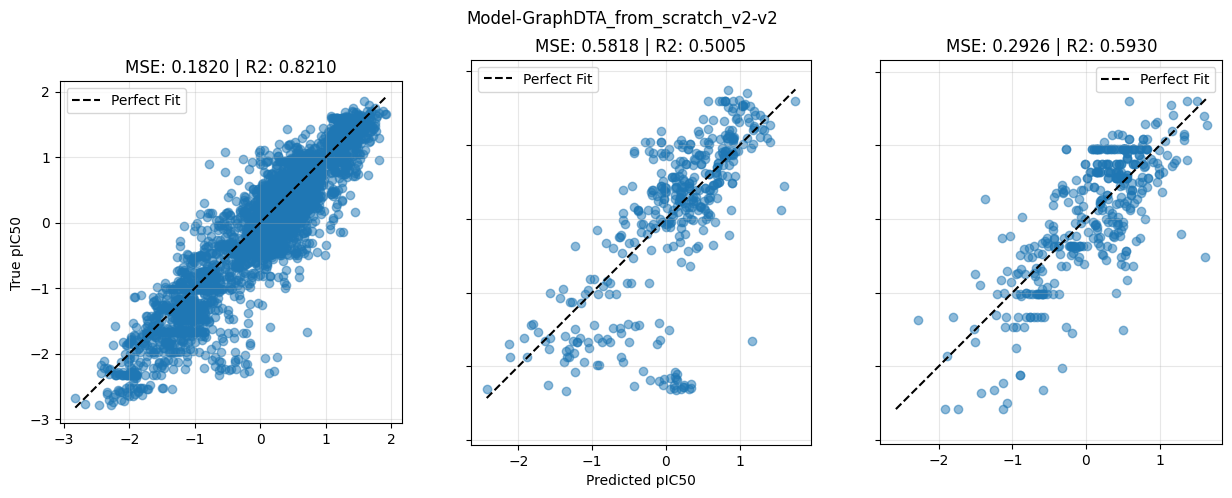

In [ ]:
# 1. Load the raw checkpoint
checkpoint = torch.load(
    os.path.join("checkpoints", "Model-GraphDTA_from_scratch_v2-v2.ckpt")
)
state_dict = checkpoint["state_dict"]

# 2. Fix the keys (Remove "model." prefix)
new_state_dict = {}
for key, value in state_dict.items():
    if key.startswith("model."):
        # Strip the first 6 characters ("model.")
        new_key = key[6:]
        new_state_dict[new_key] = value

# 3. Initialize your raw model
model_gdta = SequenceSiameseNetwork(
    molecule_encoder=uninitialized_graph_model.encode_molecule,
    sequence_encoder=seq_encoder,
)

# 4. Load the cleaned weights
model_gdta.load_state_dict(new_state_dict)
model_gdta.eval()

plot_predictions(
    model_gdta,
    (train_loader_gdta, val_loader_gdta, test_loader_gdta),
    mdm2_tensor,
    "Model-GraphDTA_from_scratch_v2-v2",
)

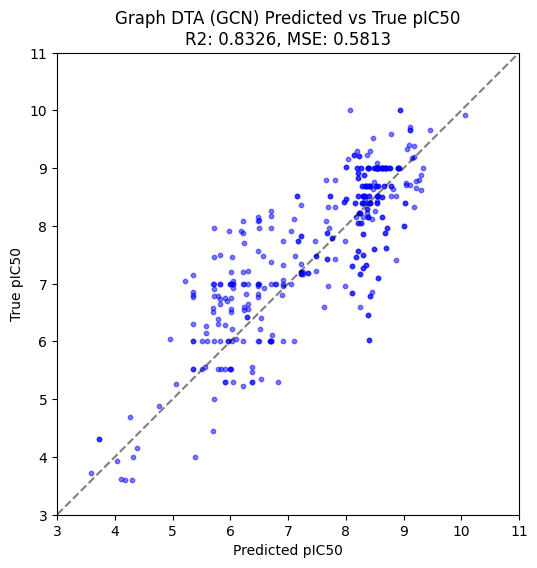

In [ ]:
df_gdta = pd.read_csv(
    os.path.join(
        ROOT, "data", "MDM2_Breaker", "processed", "graphdta_benchmark_results.csv"
    )
)

_, ax = plt.subplots(1, 1, figsize=(6, 6))
df_gdta.plot(
    x="pIC50_pred", y="pIC50", kind="scatter", alpha=0.5, color="blue", s=10, ax=ax
)
r2 = df_gdta["pIC50_pred"].corr(df_gdta["pIC50"])
mse = np.mean((df_gdta["pIC50_pred"] - df_gdta["pIC50"]) ** 2)
plt.xlim(3, 11)
plt.ylim(3, 11)
ax.set_aspect("equal", "box")
plt.plot([0, 14], [0, 14], "k--", alpha=0.5)
plt.xlabel("Predicted pIC50")
plt.ylabel("True pIC50")
plt.title(f"Graph DTA (GCN) Predicted vs True pIC50\nR2: {r2:.4f}, MSE: {mse:.4f}")
plt.show()

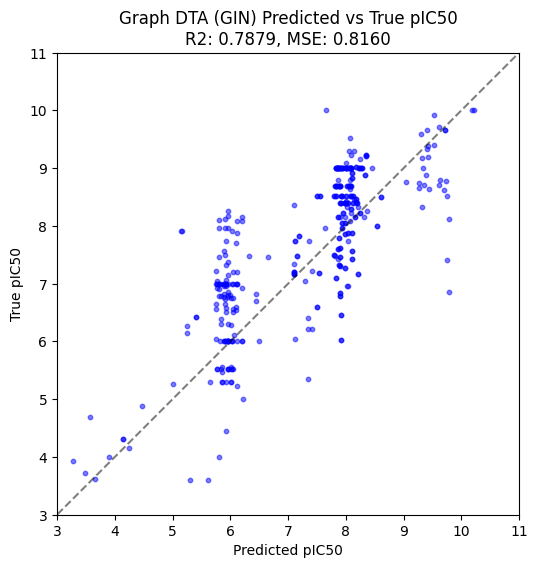

In [ ]:
df_gdta_gin_attr_masking = pd.read_csv(
    os.path.join(
        ROOT,
        "data",
        "MDM2_Breaker",
        "processed",
        "graphdta_benchmark_results_gin_attr_masking.csv",
    )
)

_, ax = plt.subplots(1, 1, figsize=(6, 6))
df_gdta_gin_attr_masking.plot(
    x="pIC50_pred", y="pIC50", kind="scatter", alpha=0.5, color="blue", s=10, ax=ax
)
r2 = df_gdta_gin_attr_masking["pIC50_pred"].corr(df_gdta_gin_attr_masking["pIC50"])
mse = np.mean(
    (df_gdta_gin_attr_masking["pIC50_pred"] - df_gdta_gin_attr_masking["pIC50"]) ** 2
)
plt.xlim(3, 11)
plt.ylim(3, 11)
ax.set_aspect("equal", "box")
plt.plot([0, 14], [0, 14], "k--", alpha=0.5)
plt.xlabel("Predicted pIC50")
plt.ylabel("True pIC50")
plt.title(f"Graph DTA (GIN) Predicted vs True pIC50\nR2: {r2:.4f}, MSE: {mse:.4f}")
plt.show()